# **Day 43: Feature Selection**
*Module 7 - Model Selection, Tuning and Explainability*

More features are not always better. Irrelevant and redundant features add noise, slow training, hurt distance-based models (curse of dimensionality, Day 30), make models harder to explain and more expensive to deploy (every feature must be computed for every pixel or customer). **Feature selection** finds a small subset that keeps (or improves) performance.

> Feature selection keeps the useful inputs and removes redundant or irrelevant ones. Fewer features make models faster, easier to explain, and sometimes more accurate.
>
> *Example:* From 60 seasonal band features, perhaps 12 carry nearly all the information for crop mapping. The rest only add noise and computation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
rng = np.random.default_rng(43)

# 300 samples, 100 features: 6 informative, 10 redundant (linear combinations), 84 noise
X, y = make_classification(n_samples=300, n_features=100, n_informative=6, n_redundant=10, n_repeated=0,
                           shuffle=False, class_sep=1.0, flip_y=0.03, random_state=0)
feature_names = [f"inf{i}" for i in range(6)] + [f"red{i}" for i in range(10)] + [f"noise{i}" for i in range(84)]
X = pd.DataFrame(X, columns=feature_names)
truth = np.array([n.startswith(("inf", "red")) for n in feature_names])
cv = StratifiedKFold(5, shuffle=True, random_state=0)
def cv_score(model, cols=None):
    return cross_val_score(model, X if cols is None else X[cols], y, cv=cv).mean()
print(f"All 100 features: logistic {cv_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))):.3f} | RF {cv_score(RandomForestClassifier(300, n_jobs=-1, random_state=0)):.3f}")
print(f"Only the 16 true features: logistic {cv_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)), list(X.columns[truth])):.3f}")

All 100 features: logistic 0.713 | RF 0.800
Only the 16 true features: logistic 0.787


## **1. Filter Methods**
Rank features by a statistic computed **independently of the final model**. Fast; ignore feature interactions.

| Filter | Captures |
|---|---|
| Variance threshold | Removes constant / near-constant features |
| ANOVA F-test (`f_classif`), correlation | Linear univariate association |
| Chi-square | Association for non-negative counts |
| **Mutual information** | Any (non-linear) univariate dependence |

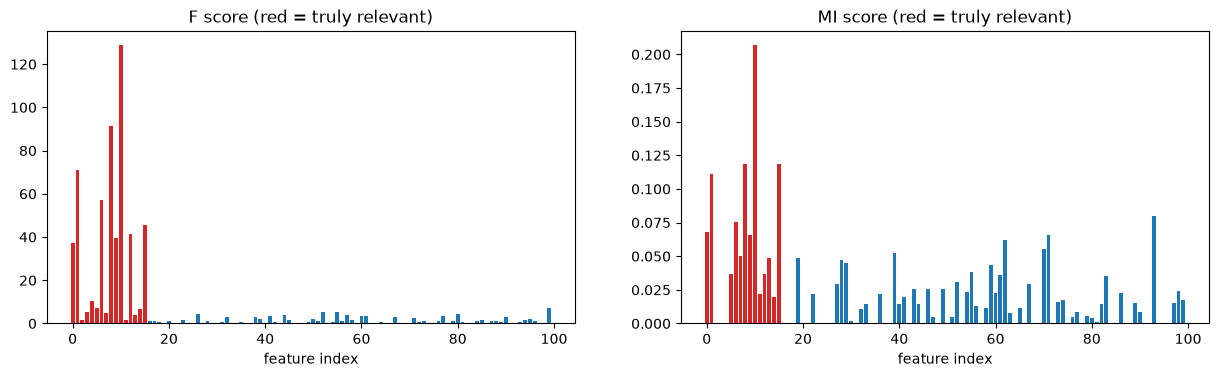

top-5  by F-test:  5 relevant | logistic CV acc (selection inside CV) 0.783
top-10 by F-test:  9 relevant | logistic CV acc (selection inside CV) 0.777
top-16 by F-test: 13 relevant | logistic CV acc (selection inside CV) 0.773
top-30 by F-test: 14 relevant | logistic CV acc (selection inside CV) 0.763


In [2]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif
F, pF = f_classif(X, y)
MI = mutual_info_classif(X, y, random_state=0)
rank = pd.DataFrame({"F": F, "MI": MI, "true": truth}, index=feature_names)
fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))
for ax, col in zip(axes, ["F", "MI"]):
    ax.bar(range(100), rank[col], color=np.where(truth, "C3", "C0")); ax.set_title(f"{col} score (red = truly relevant)"); ax.set_xlabel("feature index")
plt.show()
for k in [5, 10, 16, 30]:
    top = rank.F.nlargest(k).index
    print(f"top-{k:<2} by F-test: {truth[[feature_names.index(c) for c in top]].sum():>2} relevant | logistic CV acc (selection inside CV) "
          f"{cross_val_score(make_pipeline(StandardScaler(), SelectKBest(f_classif, k=k), LogisticRegression(max_iter=3000)), X, y, cv=cv).mean():.3f}")

## **2. Removing Redundant Features (Correlation Clustering)**
Highly correlated features carry the same information. Cluster features by $1 - |\rho|$ and keep one representative per cluster.

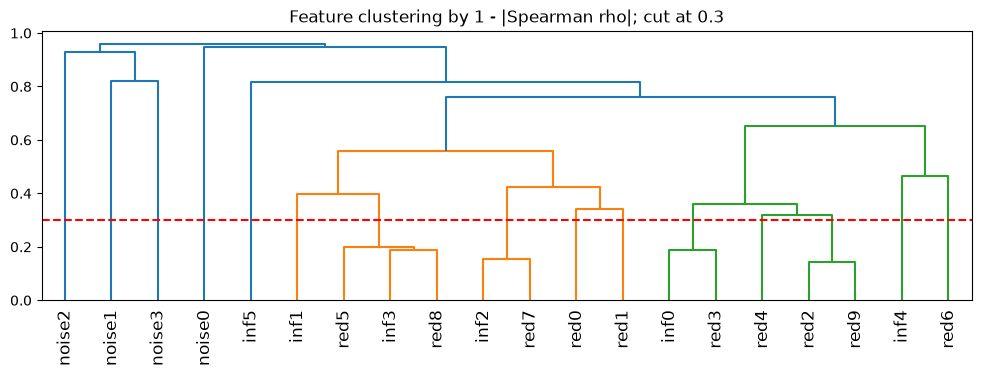

20 features -> 15 clusters


In [3]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
sub = X.iloc[:, :20]                                        # informative + redundant + a few noise
corr = sub.corr(method="spearman").abs().values
Z = linkage(squareform(1 - corr, checks=False), method="average")
plt.figure(figsize=(12, 3.5)); dendrogram(Z, labels=sub.columns.tolist(), leaf_rotation=90); plt.axhline(0.3, c="r", ls="--")
plt.title("Feature clustering by 1 - |Spearman rho|; cut at 0.3"); plt.show()
clusters = fcluster(Z, t=0.3, criterion="distance")
print(f"{sub.shape[1]} features -> {len(np.unique(clusters))} clusters")

## **3. Wrapper Methods**
Search over subsets using the **model's own performance**. Accounts for interactions; expensive; can overfit.

**RFE**: fit, drop the least important feature(s), repeat. **RFECV** chooses the number of features by CV.

RFECV kept 5 features: 5 relevant, 0 noise


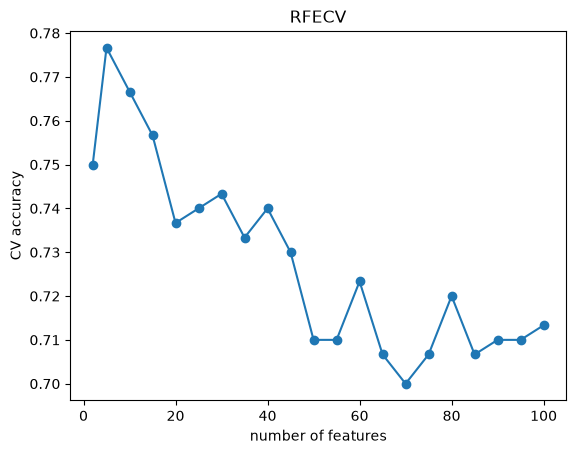

In [4]:
from sklearn.feature_selection import RFECV, SequentialFeatureSelector
rfecv = RFECV(LogisticRegression(max_iter=3000), step=5, cv=cv, scoring="accuracy", min_features_to_select=2, n_jobs=-1)
rfecv.fit(StandardScaler().fit_transform(X), y)
sel = rfecv.support_
print(f"RFECV kept {sel.sum()} features: {sel[truth].sum()} relevant, {sel[~truth].sum()} noise")
n_feats = rfecv.cv_results_["n_features"]
plt.plot(n_feats, rfecv.cv_results_["mean_test_score"], "o-"); plt.xlabel("number of features"); plt.ylabel("CV accuracy"); plt.title("RFECV"); plt.show()

In [5]:
sfs = SequentialFeatureSelector(LogisticRegression(max_iter=3000), n_features_to_select=8, direction="forward", cv=3, n_jobs=-1)
sfs.fit(StandardScaler().fit_transform(X.iloc[:, :40]), y)                    # forward selection on 40 candidates (it is slow)
print("Forward selection picked:", list(X.columns[:40][sfs.get_support()]))

Forward selection picked: ['inf0', 'inf1', 'inf5', 'red4', 'noise0', 'noise1', 'noise9', 'noise19']


## **4. Embedded Methods**
Selection happens **during training**: L1 regularisation zeroes coefficients (Day 24, 27); tree ensembles provide importances. `SelectFromModel` keeps features above a threshold.

In [6]:
from sklearn.feature_selection import SelectFromModel
l1 = make_pipeline(StandardScaler(), LogisticRegression(l1_ratio=1, solver="liblinear", C=0.1)).fit(X, y)
nz = l1[-1].coef_[0] != 0
print(f"L1 logistic (C=0.1) kept {nz.sum()}: {nz[truth].sum()} relevant, {nz[~truth].sum()} noise")
sfm = SelectFromModel(RandomForestClassifier(500, n_jobs=-1, random_state=0), threshold="2*mean").fit(X, y)
print(f"RF SelectFromModel (2 x mean importance) kept {sfm.get_support().sum()}: {sfm.get_support()[truth].sum()} relevant")

L1 logistic (C=0.1) kept 17: 6 relevant, 11 noise


RF SelectFromModel (2 x mean importance) kept 9: 9 relevant


## **5. Boruta: All-Relevant Selection with Shadow Features**
Many methods find a *minimal* good subset. **Boruta** (Kursa & Rudnicki, 2010) finds **all** relevant features, useful when we want to understand a process (which environmental drivers matter?). Idea: for every feature add a **shadow** copy with shuffled values (pure noise by construction). A real feature is relevant only if its importance beats the **best shadow** significantly often across many iterations.

In [7]:
from scipy.stats import binom
def boruta(X, y, n_iter=30, seed=0):
    r = np.random.default_rng(seed); hits = np.zeros(X.shape[1])
    for it in range(n_iter):
        shadow = X.apply(lambda c: r.permutation(c.values)).add_prefix("shadow_")
        rf = RandomForestClassifier(300, max_depth=6, n_jobs=-1, random_state=it).fit(pd.concat([X, shadow], axis=1), y)
        imp = rf.feature_importances_
        hits += imp[: X.shape[1]] > imp[X.shape[1]:].max()
    p_relevant = binom.sf(hits - 1, n_iter, 0.5)                  # P(at least this many hits by chance)
    return pd.DataFrame({"hits": hits, "p": p_relevant}, index=X.columns)

bor = boruta(X, y)
confirmed = bor.p < 0.01 / X.shape[1]                              # Bonferroni
print(f"Boruta confirmed {confirmed.sum()} features: {confirmed[truth].sum()} relevant, {confirmed[~truth].sum()} noise")
print("Confirmed:", list(bor.index[confirmed]))

Boruta confirmed 13 features: 13 relevant, 0 noise
Confirmed: ['inf0', 'inf1', 'inf3', 'inf4', 'inf5', 'red0', 'red2', 'red3', 'red4', 'red6', 'red7', 'red8', 'red9']


## **6. Selection Must Be Inside Cross-Validation**
Selecting features on the whole dataset and then cross-validating the final model leaks label information (Day 16). Put the selector in the pipeline so it is refitted in every fold.

In [8]:
noise_X = pd.DataFrame(rng.normal(size=(100, 2000))); noise_y = rng.integers(0, 2, 100)
cols = noise_X.columns[np.argsort(f_classif(noise_X, noise_y)[0])[-15:]]
print("Selection BEFORE CV on pure noise:", cross_val_score(LogisticRegression(max_iter=3000), noise_X[cols], noise_y, cv=5).mean().round(3))
print("Selection INSIDE the pipeline    :", cross_val_score(make_pipeline(SelectKBest(f_classif, k=15), LogisticRegression(max_iter=3000)), noise_X, noise_y, cv=5).mean().round(3))

Selection BEFORE CV on pure noise: 0.78
Selection INSIDE the pipeline    : 0.47


# **Part 2: Going Deeper - Stability Selection**

A single selection run is **unstable**: small changes in data change the chosen set. **Stability selection** (Meinshausen & Buhlmann, 2010) repeats L1 selection on many random half-samples and keeps features selected in a high fraction of runs. The selection threshold (typically 0.6-0.9) trades discoveries against false discoveries; the theory bounds the expected number of false selections for a given threshold and regularisation level.

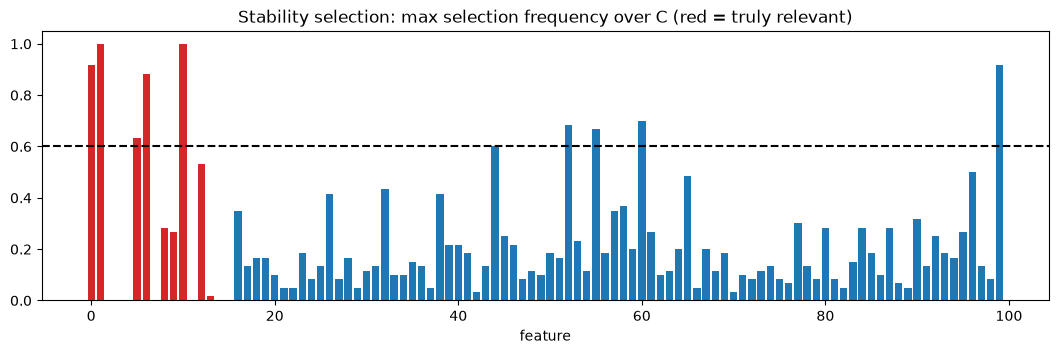

threshold 0.6: 10 stable features (5 relevant, 5 noise)
threshold 0.75:  5 stable features (4 relevant, 1 noise)
threshold 0.9:  4 stable features (3 relevant, 1 noise)
single L1 fit for comparison: 17 features (6 relevant, 11 noise)


In [9]:
def stability_selection(X, y, C_values=(0.05, 0.1, 0.2), n_runs=60, seed=0):
    r = np.random.default_rng(seed); freq = np.zeros((len(C_values), X.shape[1]))
    Xs = StandardScaler().fit_transform(X)
    for i, C in enumerate(C_values):
        for _ in range(n_runs):
            idx = r.choice(len(y), len(y) // 2, replace=False)
            m = LogisticRegression(l1_ratio=1, solver="liblinear", C=C).fit(Xs[idx], y[idx])
            freq[i] += m.coef_[0] != 0
    return freq / n_runs

freq = stability_selection(X, y)
max_freq = freq.max(0)
plt.figure(figsize=(13, 3.5)); plt.bar(range(100), max_freq, color=np.where(truth, "C3", "C0")); plt.axhline(0.6, c="k", ls="--")
plt.title("Stability selection: max selection frequency over C (red = truly relevant)"); plt.xlabel("feature"); plt.show()
for thr in [0.6, 0.75, 0.9]:
    stable = max_freq >= thr
    print(f"threshold {thr}: {stable.sum():>2} stable features ({stable[truth].sum()} relevant, {stable[~truth].sum()} noise)")
print(f"single L1 fit for comparison: {nz.sum()} features ({nz[truth].sum()} relevant, {nz[~truth].sum()} noise)")

### Which method when?

| Goal | Method |
|---|---|
| Quick clean-up | Variance threshold, correlation clustering |
| Many features, need speed | Filters (MI, F-test) inside the pipeline |
| Best predictive subset for a specific model | RFECV, sequential selection, L1 |
| Scientific understanding: all drivers that matter | Boruta, stability selection, permutation importance |
| Final paper | Report the procedure, keep it inside CV, report stability |

## **Practice Problems**
1. Combine correlation clustering (keep one feature per cluster) and RFECV. How many features remain, and what is the CV accuracy?
2. Run Boruta with `n_iter=60`. Do more noise features get rejected?
3. Implement backward elimination with `SequentialFeatureSelector(direction="backward")` on the first 25 features.
4. *(Advanced)* Repeat stability selection on a dataset where the informative features are highly correlated with each other (use `make_classification(..., n_redundant=20)`). How do Lasso and stability selection behave?

In [10]:
# Solution 1
full_corr = X.corr(method="spearman").abs().values
cl = fcluster(linkage(squareform(1 - full_corr, checks=False), "average"), t=0.3, criterion="distance")
reps = [X.columns[np.flatnonzero(cl == c)[0]] for c in np.unique(cl)]
r2 = RFECV(LogisticRegression(max_iter=3000), step=2, cv=cv, n_jobs=-1).fit(StandardScaler().fit_transform(X[reps]), y)
print(f"{len(reps)} cluster representatives -> RFECV kept {r2.support_.sum()} | CV acc {r2.cv_results_['mean_test_score'].max():.3f}")
# Solution 2
bor60 = boruta(X, y, n_iter=60)
print("Boruta 60 iterations confirmed:", (bor60.p < 0.01 / 100).sum())
# Solution 3
bwd = SequentialFeatureSelector(LogisticRegression(max_iter=3000), n_features_to_select=6, direction="backward", cv=3, n_jobs=-1).fit(StandardScaler().fit_transform(X.iloc[:, :25]), y)
print("Backward elimination kept:", list(X.columns[:25][bwd.get_support()]))
# Solution 4
Xr, yr = make_classification(300, 60, n_informative=4, n_redundant=20, shuffle=False, random_state=3)
fr = stability_selection(pd.DataFrame(Xr), yr).max(0)
print("stable among first 24 (relevant):", (fr[:24] >= 0.6).sum(), "| among noise:", (fr[24:] >= 0.6).sum())

95 cluster representatives -> RFECV kept 3 | CV acc 0.787


Boruta 60 iterations confirmed: 13


Backward elimination kept: ['inf5', 'red0', 'red5', 'red6', 'noise6', 'noise7']
stable among first 24 (relevant): 4 | among noise: 3


## **Key References**
- Guyon, I., & Elisseeff, A. (2003). An introduction to variable and feature selection. *JMLR*, 3, 1157-1182.
- Guyon, I., Weston, J., Barnhill, S., & Vapnik, V. (2002). Gene selection for cancer classification using support vector machines. *Machine Learning*, 46, 389-422 (RFE).
- Kursa, M. B., & Rudnicki, W. R. (2010). Feature selection with the Boruta package. *Journal of Statistical Software*, 36(11), 1-13.
- Meinshausen, N., & Buhlmann, P. (2010). Stability selection. *Journal of the Royal Statistical Society B*, 72(4), 417-473.
- Peng, H., Long, F., & Ding, C. (2005). Feature selection based on mutual information: criteria of max-dependency, max-relevance, and min-redundancy. *IEEE TPAMI*, 27(8), 1226-1238.
- Georganos, S. et al. (2018). Less is more: optimizing classification performance through feature selection in a very-high-resolution remote sensing object-based urban application. *GIScience & Remote Sensing*, 55(2), 221-242.